# 06. Interpretabilidade e Validação para o Negócio

## 1. Importando bibliotecas

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

In [2]:
import joblib

final_model = joblib.load(MODELS_DIR / "modelo_final.joblib")
final_model_name = (PROCESSED_DIR / "modelo_final_nome.txt").read_text().strip()

X_train, X_test, y_train, y_test = data_prep.load_processed_split()
features = list(X_train.columns)
target = data_prep.TARGET

baseline = modeling.get_baseline()
baseline.fit(X_train, y_train)
baseline_metrics = evaluation.regression_metrics(y_test, baseline.predict(X_test))

final_pred = final_model.predict(X_test)
final_metrics = evaluation.regression_metrics(y_test, final_pred)

print("Modelo final:", final_model_name, "(escolhido pelo RMSE médio de cross-validation, ver notebook 05)")
final_metrics

Modelo final: Ridge (tuned) (escolhido pelo RMSE médio de cross-validation, ver notebook 05)


{'MAE': 288.25673623715903,
 'RMSE': 357.3959786837917,
 'R2': 0.5275961823109607,
 'MAPE': 0.13092617225067085}

## 2. Feature Importance, Permutation e SHAP

Foram utilizadas três formas complementares de interpretar o modelo:

- **Importância nativa**: os coeficientes do modelo, se ele for linear, ou o `feature_importances_`, se for baseado em árvore ou boosting. Incluímos também o Random Forest como referência não linear, só para efeito de comparação.
- **Permutation Importance**: uma medida que funciona para qualquer tipo de modelo.
- **SHAP**: a contribuição de cada feature em cada previsão, tanto de forma global quanto local.


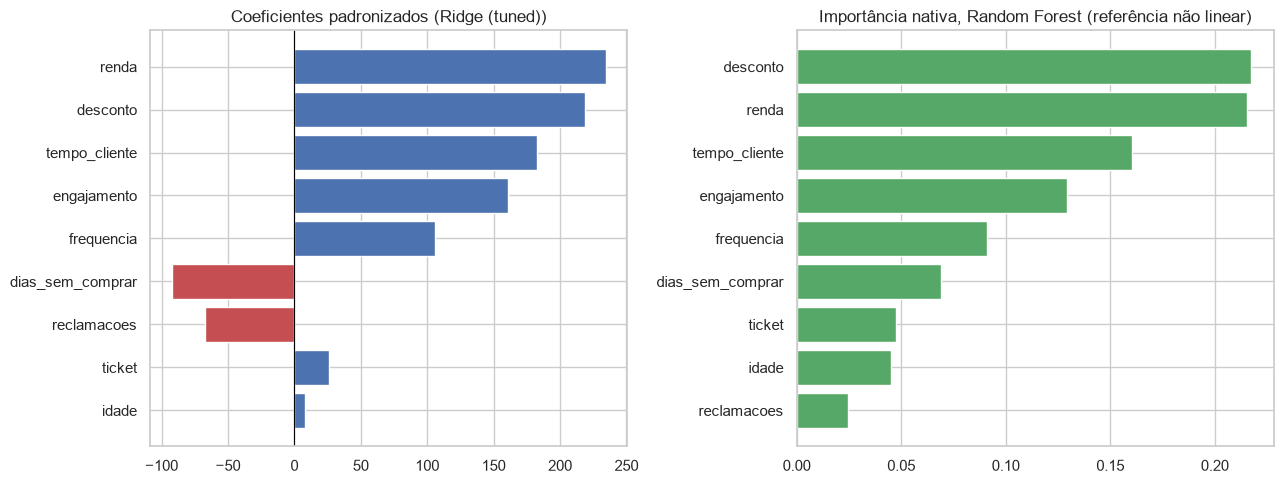

In [3]:
native_imp = interpretability.native_importance(final_model, features)
is_linear = hasattr(final_model.named_steps["model"], "coef_")
native_label = f"{'Coeficientes padronizados' if is_linear else 'Importância nativa'} ({final_model_name})"

rf_reference = modeling.get_models()["RandomForest"]
rf_reference.fit(X_train, y_train)
rf_imp = pd.Series(rf_reference.named_steps["model"].feature_importances_, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_native = ["#4C72B0" if v >= 0 else "#C44E52" for v in native_imp.values]
axes[0].barh(native_imp.index[::-1], native_imp.values[::-1], color=colors_native[::-1])
axes[0].set_title(native_label)
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(rf_imp.index[::-1], rf_imp.values[::-1], color="#55A868")
axes[1].set_title("Importância nativa, Random Forest (referência não linear)")
plt.tight_layout()
plt.show()

- renda, desconto, tempo_cliente, engajamento: as 4 mais importantes, confirmadas pelos dois métodos.
- renda/desconto/tempo_cliente/engajamento sobem o gasto; dias_sem_comprar/reclamacoes derrubam (só o Ridge mostra sinal).
- idade, ticket, reclamacoes: menos relevantes.

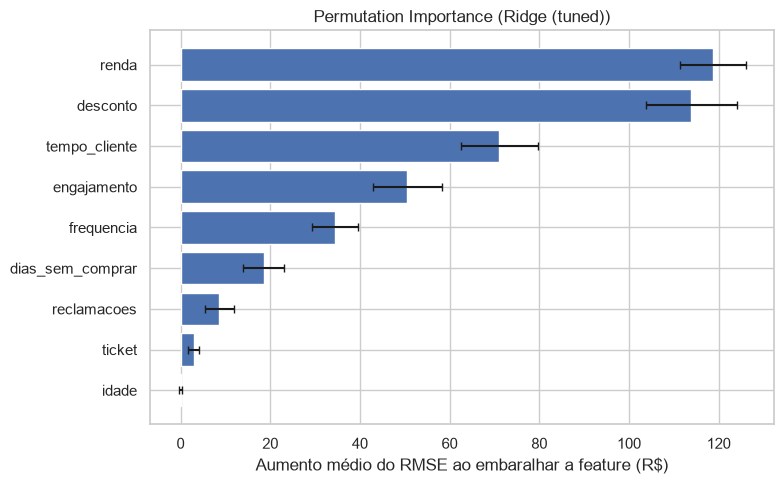

In [4]:
perm_df = interpretability.permutation_importance_df(final_model, X_test, y_test, features)
perm_df.to_csv(PROCESSED_DIR / "permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
order = perm_df.sort_values("importancia_media")
ax.barh(order["feature"], order["importancia_media"], xerr=order["importancia_std"], color="#4C72B0", capsize=3)
ax.set_xlabel("Aumento médio do RMSE ao embaralhar a feature (R$)")
ax.set_title(f"Permutation Importance ({final_model_name})")
plt.tight_layout()
plt.show()

Background dataset has 1657 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1657 when initializing the masker.


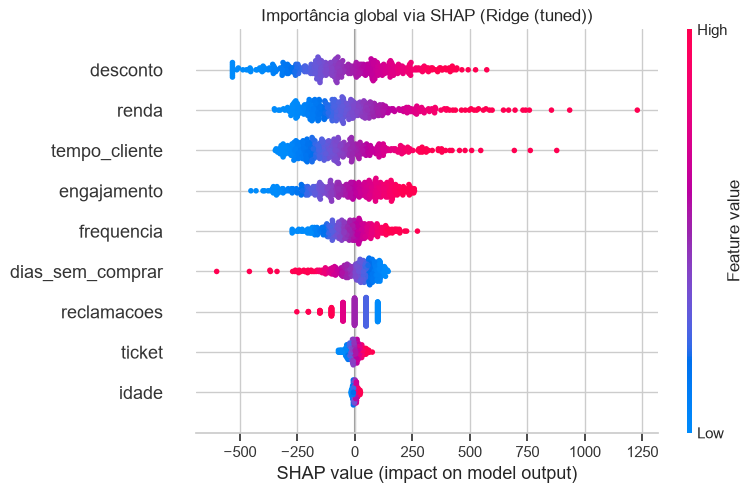

In [5]:
explainer, shap_values = interpretability.shap_explain(final_model, X_train, X_test, features)

import shap
shap.summary_plot(shap_values, features=X_test, feature_names=features, show=False)
plt.title(f"Importância global via SHAP ({final_model_name})")
plt.tight_layout()
plt.show()

## 12. Robustez por segmento e validação de negócio

In [8]:
seg_renda = evaluation.segment_metrics(y_test, final_pred, X_test["renda"], label="faixa_renda")
seg_renda.to_csv(PROCESSED_DIR / "metrics_por_faixa_renda.csv", index=False)
seg_renda

,faixa_renda,n,MAE,RMSE,MAPE
0,"(1474.738, 4201.634]",104,293.422542,359.857761,0.142327
1,"(4201.634, 5784.094]",104,275.053989,350.654879,0.132498
2,"(5784.094, 7606.146]",103,310.907634,382.745505,0.142782
3,"(7606.146, 23468.803]",104,273.860577,334.899052,0.106212


- Erro (MAE/RMSE) não varia muito entre faixas de renda, fica entre R$274 e R$311.
- MAPE (erro relativo) é menor na faixa de renda mais alta (10,6%), maior nas 3 faixas mais baixas (~13-14%), modelo relativamente mais preciso pra clientes de renda alta.


In [10]:
resid = y_test.values - final_pred
bp = evaluation.breusch_pagan_test(resid, X_test)

print(f"MAE: R$ {final_metrics['MAE']:.1f} ({100*final_metrics['MAE']/y_test.mean():.1f}% do gasto médio)")
print(f"RMSE: R$ {final_metrics['RMSE']:.1f}")
print(f"R²: {final_metrics['R2']:.3f}")
print(f"MAPE: {100*final_metrics['MAPE']:.1f}%")
print(f"Redução de RMSE vs. baseline: {100*(1 - final_metrics['RMSE']/baseline_metrics['RMSE']):.1f}%")
print(f"Breusch-Pagan p-valor: {bp['lm_pvalue']:.3f}")

MAE: R$ 288.3 (12.2% do gasto médio)
RMSE: R$ 357.4
R²: 0.528
MAPE: 13.1%
Redução de RMSE vs. baseline: 31.3%
Breusch-Pagan p-valor: 0.770


- Erra em média R$ 288 por cliente (12,2% do gasto médio).
- Explica 52,8% da variação do gasto (R²).
- 31,3% melhor que só prever a média (baseline).
- Breusch-Pagan (p=0,77): sem heterocedasticidade, o erro não varia sistematicamente com o valor previsto, resíduos bem-comportados.

Modelo funciona, com folga sobre o baseline, mas R² moderado, bom pra ranking/priorização, não pra precisão financeira exata.